In [18]:
import pandas as pd
import numpy as np
import numpy as np
from time import time
import warnings
from sklearn import datasets

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from scipy.stats import randint, loguniform
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")

wine_data = pd.read_csv('winequality-red.csv', sep=';')


print("--- Initial Data Overview ---")
print("\nFirst 5 Rows:")
print(wine_data.head())

print(f"\nDataset Shape: {wine_data.shape}")

print("\nDataset Info:")
wine_data.info()

print("\nDescriptive Statistics:")
print(wine_data.describe())

X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

print("\n--- Data Preparation ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Unique target values: {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5, stratify=y
)

print("\n--- Data Splitting ---")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

--- Initial Data Overview ---

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5

Starting RandomizedSearchCV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
RandomizedSearchCV took 5.49 seconds for 1 candidate settings.

Best parameters found:
{'regress__activation': 'relu', 'regress__alpha': np.float64(0.00018875593672162917), 'regress__hidden_layer_sizes': (50, 25), 'regress__solver': 'sgd'}

--- Performance on Test Data ---
Testing MSE: 0.4438
Testing R-squared (R2): 0.3154
Testing Mean Absolute Deviation (MAD): 0.5121

--- Performance on Training Data ---
Training MSE: 0.3178
Training R-squared (R2): 0.5135
Training Mean Absolute Deviation (MAD): 0.4392


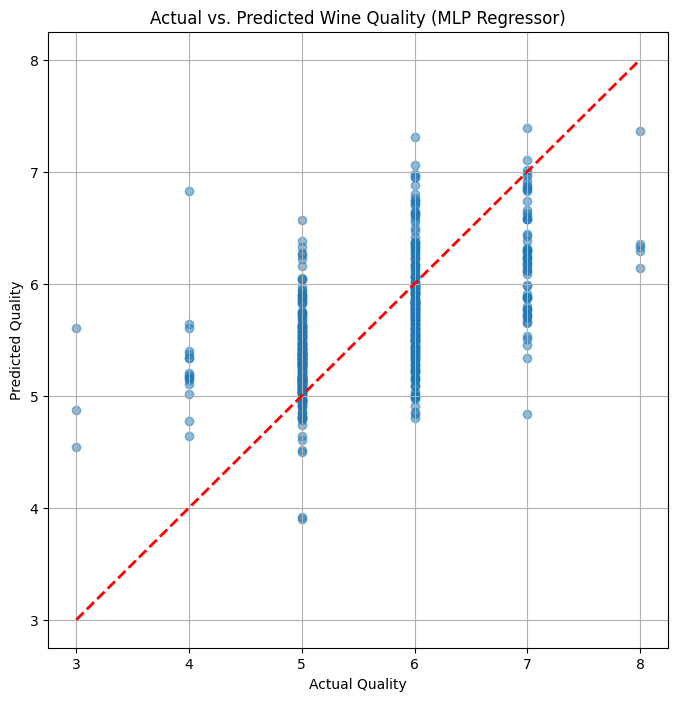

In [ ]:
pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("regress", MLPRegressor(max_iter=5000, random_state=5))] # Add random_state for reproducibility
)

model_params = {
    'regress__alpha': loguniform(1e-4, 10),
    'regress__solver': ['sgd', 'adam'],
    'regress__hidden_layer_sizes': [
        (100,),              
        (50, 25),           
    ],
    'regress__activation': ['tanh', 'relu'] 
}


n_iter = 1
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=model_params,
    n_iter=n_iter,
    verbose=3,
    random_state=5
)

print("Starting RandomizedSearchCV...")
start = time()
random_search.fit(X_train, y_train)
print(f"RandomizedSearchCV took {time() - start:.2f} seconds for {n_iter} candidate settings.")
print("\nBest parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2  = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2) # The "perfect prediction" line
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs. Predicted Wine Quality (MLP Regressor)")
plt.grid()
plt.show()

Starting SVR hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best SVR parameters found:
{'svr__C': np.float64(8.120950813436846), 'svr__degree': 4, 'svr__gamma': np.float64(0.012575661600286142), 'svr__kernel': 'rbf'}

--- SVR Performance on Test Data ---
Testing MSE: 0.4151
Testing R-squared (R2): 0.3598
Testing Mean Absolute Deviation (MAD): 0.4871


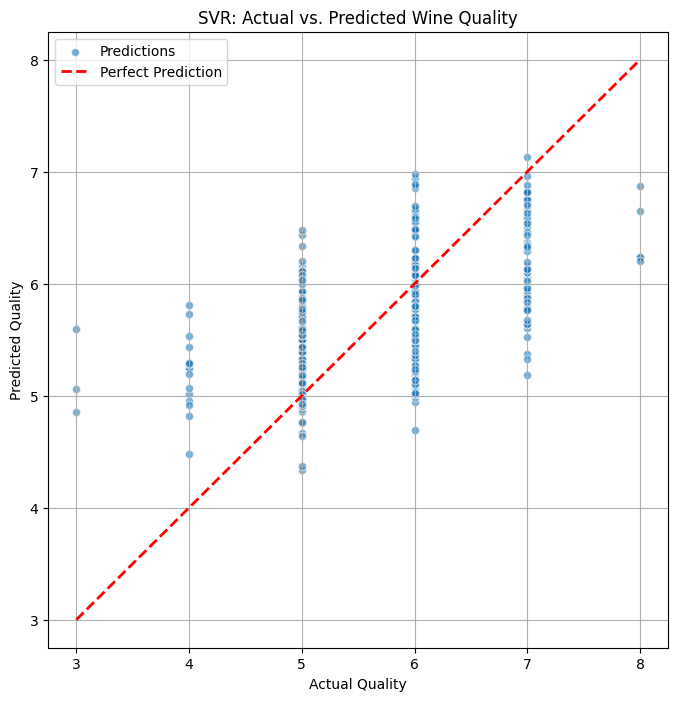

In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__C': loguniform(1e-1, 1e3),
    'svr__gamma': loguniform(1e-4, 1e-1),
    'svr__kernel': ['rbf', 'poly', 'sigmoid'],
    'svr__degree': [2, 3, 4]
}

n_iter = 1
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=model_params,
    n_iter=n_iter,
    verbose=3,
    random_state=5
)

print("Starting SVR hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\nBest SVR parameters found:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)
test_mad = mean_absolute_error(y_test, y_pred_test)

train_mse = mean_squared_error(y_train, y_pred_train)
train_r2  = r2_score(y_train, y_pred_train)
train_mad = mean_absolute_error(y_train, y_pred_train)

print("\n--- Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

print("\n--- Performance on Training Data ---")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R-squared (R2): {train_r2:.4f}")
print(f"Training Mean Absolute Deviation (MAD): {train_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_svr, alpha=0.6, edgecolors='w', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("SVR: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best XGBoost parameters found:
{'colsample_bytree': np.float64(0.7890401504728666), 'learning_rate': np.float64(0.06631636859837549), 'max_depth': 8, 'n_estimators': 180, 'subsample': np.float64(0.9458418379157242)}

--- XGBoost Performance on Test Data ---
Testing MSE: 0.3429
Testing R-squared (R2): 0.4710
Testing Mean Absolute Deviation (MAD): 0.4059


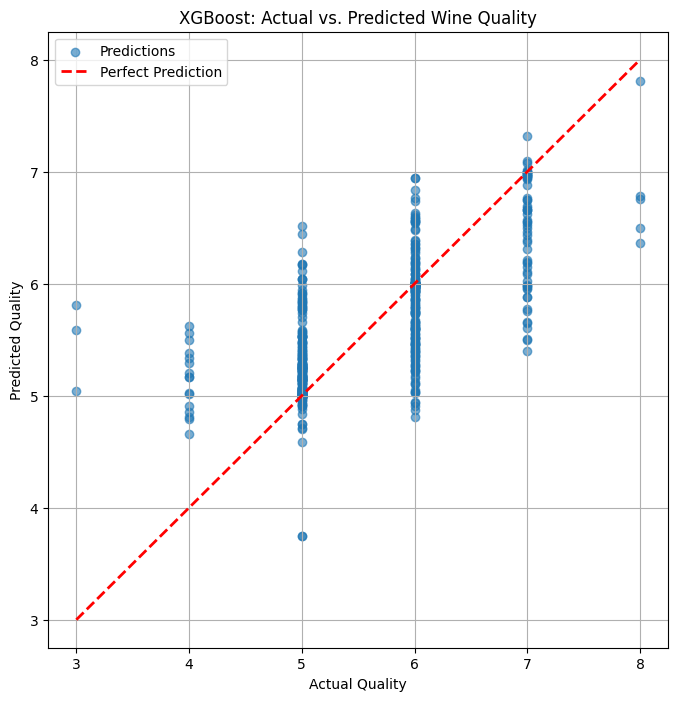

In [21]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=5)

param_grid = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    random_state=5,
    verbose=1,
    n_jobs=1
)

print("Starting XGBoost hyperparameter tuning...")
random_search_xgb.fit(X_train, y_train)

print("\nBest XGBoost parameters found:")
print(random_search_xgb.best_params_)

best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_xgb)
test_r2  = r2_score(y_test, y_pred_xgb)
test_mad = mean_absolute_error(y_test, y_pred_xgb)

print("\n--- XGBoost Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("XGBoost: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 25),
    'min_samples_leaf': randint(1, 5)
}

rf = RandomForestRegressor(random_state=5)

rand_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=5,
    verbose=1,
    n_jobs=-1
)

print("Starting Random Forest hyperparameter tuning...")
rand_search_rf.fit(X_train, y_train)

best_rf = rand_search_rf.best_estimator_

print('\nBest hyperparameters:', rand_search_rf.best_params_)

y_pred_rf = best_rf.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_rf)
test_r2  = r2_score(y_test, y_pred_rf)
test_mad = mean_absolute_error(y_test, y_pred_rf)

print("\n--- Random Forest Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Random Forest: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()

Starting Random Forest hyperparameter tuning...


ModuleNotFoundError: No module named '_posixsubprocess'

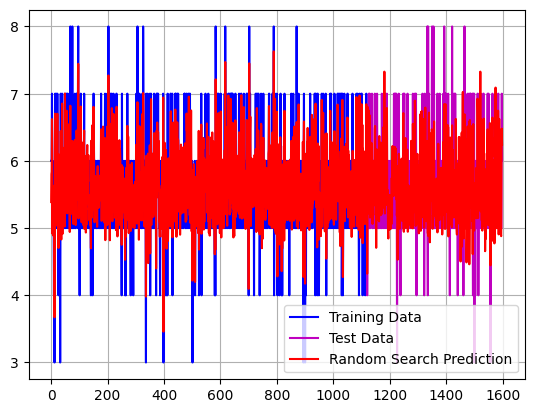

Training MSE: 0.22075286396951185
Testing MSE: 0.4000604614056735
Training R2: 0.6576755079409022, Training MAD: 0.3673741949969842
Testing R2: 0.4004362682026398, Testing MAD: 0.47784780980831315


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

gbr = GradientBoostingRegressor(random_state=5)

param_grid = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'min_samples_leaf': randint(1, 5)
}

random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    random_state=5,
    verbose=1,
    n_jobs=-1
)

print("Starting Gradient Boosting hyperparameter tuning...")
random_search_gbr.fit(X_train, y_train)

print("\nBest Gradient Boosting parameters found:")
print(random_search_gbr.best_params_)

best_gbr = random_search_gbr.best_estimator_
y_pred_gbr = best_gbr.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_gbr)
test_r2  = r2_score(y_test, y_pred_gbr)
test_mad = mean_absolute_error(y_test, y_pred_gbr)

print("\n--- Gradient Boosting Performance on Test Data ---")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Testing R-squared (R2): {test_r2:.4f}")
print(f"Testing Mean Absolute Deviation (MAD): {test_mad:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_gbr, alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Gradient Boosting: Actual vs. Predicted Wine Quality")
plt.legend()
plt.grid(True)
plt.show()